# 03 - Ingredient Data Cleaning
## Paulas Choice Ingredient Dictionary Analysis

This notebook cleans and explores the scraped ingredient data from Paulas Choice...

### Objectives:
1. Load both CSV files
2. Explore data structure and quality
3. Identify and remove duplicates
4. Create a clean, unified dataset
5. Perform exploratory data analysis

In [1345]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data

In [1346]:
df1 = pd.read_csv('../data/raw/paulas_choice_perfect_glance_1.csv')
df2 = pd.read_csv('../data/raw/paulas_choice_perfect_glance_2.csv')

print(f"File 1: {df1.shape}")
print(f"File 2: {df2.shape}")
print(f"\nTotal rows before merge: {df1.shape[0] + df2.shape[0]}")

File 1: (2000, 9)
File 2: (543, 9)

Total rows before merge: 2543


## 2. Initial Data Exploration

In [1347]:
# Display column names
print(df1.columns.tolist())

['web_scraper_order', 'web_scraper_start_url', 'ingredient_link', 'ingredient_link-href', 'ingredient_name', 'rating', 'benefits', 'categories', 'INFO_GLANCE']


In [1348]:
print("First 3 rows from File 1:")
display(df1.head(3))

print("\nFirst 3 rows from File 2:")
display(df2.head(3))

First 3 rows from File 1:


,web_scraper_order,web_scraper_start_url,ingredient_link,ingredient_link-href,ingredient_name,rating,benefits,categories,INFO_GLANCE
0,1766113077-1,https://www.paulaschoice.com/ingredient-dictionary?crefn1=ingredientRating&crefv1=Best%7CGood%7C...,Read More,https://www.paulaschoice.com/ingredient-dictionary/ingredient-alcohol.html?crefn1=ingredientRati...,Alcohol,Rating: Average,NaN,"Categories: Emollient, Cleansing Agent, Irritant",NaN
1,1766113083-2,https://www.paulaschoice.com/ingredient-dictionary?crefn1=ingredientRating&crefv1=Best%7CGood%7C...,Read More,https://www.paulaschoice.com/ingredient-dictionary/ingredient-alcloxa.html?crefn1=ingredientRati...,Alcloxa,Rating: Average,NaN,"Categories: Irritant, Exfoliant, Cleansing Agent",Combination of sodium salt of aluminum + allantoinUsed for wound healing and burn treatmentHas a...
2,1766113088-3,https://www.paulaschoice.com/ingredient-dictionary?crefn1=ingredientRating&crefv1=Best%7CGood%7C...,Read More,https://www.paulaschoice.com/ingredient-dictionary/ingredient-albumen.html?crefn1=ingredientRati...,Albumen,Rating: Average,NaN,Categories: Film-Forming Agent,Another name for egg whiteUsed as food and as a food additiveHas skin tightening properties that...



First 3 rows from File 2:


,web_scraper_order,web_scraper_start_url,ingredient_link,ingredient_link-href,ingredient_name,rating,benefits,categories,INFO_GLANCE
0,1766125183-1,https://www.paulaschoice.com/ingredient-dictionary?crefn1=ingredientRating&crefv1=Best%7CGood%7C...,Read More,https://www.paulaschoice.com/ingredient-dictionary/ingredient-zingiber-zerumbet-extract.html?cso...,Zingiber Zerumbet Extract,Rating: Worst,Benefits: Hydration,"Categories: Plant Extracts, Humectant, Irritant",NaN
1,1766125188-2,https://www.paulaschoice.com/ingredient-dictionary?crefn1=ingredientRating&crefv1=Best%7CGood%7C...,Read More,https://www.paulaschoice.com/ingredient-dictionary/ingredient-zingiber-zerumbet.html?csortb1=ing...,Zingiber Zerumbet,Rating: Worst,Benefits: Hydration,"Categories: Plant Extracts, Humectant, Irritant",NaN
2,1766125193-3,https://www.paulaschoice.com/ingredient-dictionary?crefn1=ingredientRating&crefv1=Best%7CGood%7C...,Read More,https://www.paulaschoice.com/ingredient-dictionary/ingredient-zinc-carbonate.html?csortb1=ingred...,Zinc Carbonate,Rating: Worst,NaN,Categories: Occlusive/Opacifying Agent,NaN


### Data types and missing values

In [1349]:
print("File 1 Info:")
df1.info()

File 1 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   web_scraper_order      2000 non-null   object
 1   web_scraper_start_url  2000 non-null   object
 2   ingredient_link        2000 non-null   object
 3   ingredient_link-href   2000 non-null   object
 4   ingredient_name        1999 non-null   object
 5   rating                 1995 non-null   object
 6   benefits               1533 non-null   object
 7   categories             1970 non-null   object
 8   INFO_GLANCE            1159 non-null   object
dtypes: object(9)
memory usage: 140.8+ KB


In [1350]:
print("File 2 Info:")
df2.info()

File 2 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 543 entries, 0 to 542
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   web_scraper_order      543 non-null    object
 1   web_scraper_start_url  543 non-null    object
 2   ingredient_link        543 non-null    object
 3   ingredient_link-href   543 non-null    object
 4   ingredient_name        543 non-null    object
 5   rating                 538 non-null    object
 6   benefits               120 non-null    object
 7   categories             532 non-null    object
 8   INFO_GLANCE            231 non-null    object
dtypes: object(9)
memory usage: 38.3+ KB


## 3. Check for Duplicates

In [1351]:
# Check for duplicate ingredient names within each file
# Wealsoonly check ingredient_name for duplicates, not rating/benefits/categories(those columns will naturally have duplicates across different ingredients)
dup1 = df1['ingredient_name'].duplicated().sum()
print(f"Count: {dup1}")

dup2 = df2['ingredient_name'].duplicated().sum()
print(f"Count: {dup2}")


Count: 5
Count: 3


In [1352]:
# Show duplicate examples if they exist
if dup1 > 0:
    print("File 1:")
    duplicates = df1[df1['ingredient_name'].duplicated(keep=False)].sort_values('ingredient_name')
    display(duplicates[['ingredient_name', 'rating', 'categories']].head(15))

if dup2 > 0:
    print("File 2:")
    duplicates = df2[df2['ingredient_name'].duplicated(keep=False)].sort_values('ingredient_name')
    display(duplicates[['ingredient_name', 'rating', 'categories']].head(15))

File 1:


,ingredient_name,rating,categories
1954,AHA,Rating: Best,"Categories: Exfoliant, Humectant"
1975,AHA,Rating: Best,"Categories: Exfoliant, Humectant"
1891,BHA (Beta Hydroxy Acid),Rating: Best,Categories: Exfoliant
1894,BHA (Beta Hydroxy Acid),Rating: Best,Categories: Exfoliant
1434,Persea Gratissima (Avocado) Oil,Rating: Best,"Categories: Emollient, Antioxidant, Plant Extracts"
1435,Persea Gratissima (Avocado) Oil,Rating: Best,"Categories: Emollient, Antioxidant, Plant Extracts"
1331,Rubus Idaeus (Raspberry) Fruit Extract,Rating: Best,"Categories: Antioxidant, Plant Extracts"
1332,Rubus Idaeus (Raspberry) Fruit Extract,Rating: Best,"Categories: Antioxidant, Plant Extracts"
1263,What Does SPF (Sun Protection Factor) Mean?,NaN,NaN
1272,What Does SPF (Sun Protection Factor) Mean?,NaN,NaN


File 2:


,ingredient_name,rating,categories
241,Advanced Glycation Endproduct (AGE),Rating: Worst,Categories: Irritant
243,Advanced Glycation Endproduct (AGE),Rating: Worst,Categories: Irritant
242,Pterocarpus Santalinus,Rating: Average,"Categories: Antioxidant, Plant Extracts, Fragrance: Synthetic and Natural, Irritant"
393,Pterocarpus Santalinus,Rating: Average,"Categories: Antioxidant, Plant Extracts, Fragrance: Synthetic and Natural, Irritant"
13,The Difference Between UVA and UVB Rays,NaN,NaN
14,The Difference Between UVA and UVB Rays,NaN,NaN


In [1353]:

# Remve article titles by index
df1 = df1.drop([1263, 1272])
df2 = df2.drop([13, 14])


In [1354]:
# Show duplicate examples if they exist
if dup1 > 0:
    print("File 1:")
    duplicates = df1[df1['ingredient_name'].duplicated(keep=False)].sort_values('ingredient_name')
    display(duplicates[['ingredient_name', 'rating', 'categories']].head(15))

if dup2 > 0:
    print("File 2:")
    duplicates = df2[df2['ingredient_name'].duplicated(keep=False)].sort_values('ingredient_name')
    display(duplicates[['ingredient_name', 'rating', 'categories']].head(15))

File 1:


,ingredient_name,rating,categories
1954,AHA,Rating: Best,"Categories: Exfoliant, Humectant"
1975,AHA,Rating: Best,"Categories: Exfoliant, Humectant"
1891,BHA (Beta Hydroxy Acid),Rating: Best,Categories: Exfoliant
1894,BHA (Beta Hydroxy Acid),Rating: Best,Categories: Exfoliant
1434,Persea Gratissima (Avocado) Oil,Rating: Best,"Categories: Emollient, Antioxidant, Plant Extracts"
1435,Persea Gratissima (Avocado) Oil,Rating: Best,"Categories: Emollient, Antioxidant, Plant Extracts"
1331,Rubus Idaeus (Raspberry) Fruit Extract,Rating: Best,"Categories: Antioxidant, Plant Extracts"
1332,Rubus Idaeus (Raspberry) Fruit Extract,Rating: Best,"Categories: Antioxidant, Plant Extracts"


File 2:


,ingredient_name,rating,categories
241,Advanced Glycation Endproduct (AGE),Rating: Worst,Categories: Irritant
243,Advanced Glycation Endproduct (AGE),Rating: Worst,Categories: Irritant
242,Pterocarpus Santalinus,Rating: Average,"Categories: Antioxidant, Plant Extracts, Fragrance: Synthetic and Natural, Irritant"
393,Pterocarpus Santalinus,Rating: Average,"Categories: Antioxidant, Plant Extracts, Fragrance: Synthetic and Natural, Irritant"


In [1355]:
# Check for overlap between files
overlap_names = df1[df1['ingredient_name'].isin(df2['ingredient_name'])]['ingredient_name'].unique()
print(f"Number of overlapping ingredients between files: {len(overlap_names)}")

if len(overlap_names) > 0:
    print(sorted(overlap_names)[:10])

Number of overlapping ingredients between files: 2
['Albumen', 'The Ultimate Guide to pH and Your Skin']


## 4. Merge and Deduplicate

In [1356]:
# Merge files
df_clean = pd.concat([df1, df2], ignore_index=True)
before = len(df_clean)

# Remove duplicates
df_clean = df_clean.drop_duplicates(subset='ingredient_name', keep='first')
after = len(df_clean)

print(f"Before: {before} rows => After: {after} rows (removed {before - after} duplicates)")

Before: 2539 rows => After: 2531 rows (removed 8 duplicates)


In [1357]:
# Reset index
df_clean = df_clean.reset_index(drop=True)

display(df_clean.head(10))

,web_scraper_order,web_scraper_start_url,ingredient_link,ingredient_link-href,ingredient_name,rating,benefits,categories,INFO_GLANCE
0,1766113077-1,https://www.paulaschoice.com/ingredient-dictionary?crefn1=ingredientRating&crefv1=Best%7CGood%7C...,Read More,https://www.paulaschoice.com/ingredient-dictionary/ingredient-alcohol.html?crefn1=ingredientRati...,Alcohol,Rating: Average,NaN,"Categories: Emollient, Cleansing Agent, Irritant",NaN
1,1766113083-2,https://www.paulaschoice.com/ingredient-dictionary?crefn1=ingredientRating&crefv1=Best%7CGood%7C...,Read More,https://www.paulaschoice.com/ingredient-dictionary/ingredient-alcloxa.html?crefn1=ingredientRati...,Alcloxa,Rating: Average,NaN,"Categories: Irritant, Exfoliant, Cleansing Agent",Combination of sodium salt of aluminum + allantoinUsed for wound healing and burn treatmentHas a...
2,1766113088-3,https://www.paulaschoice.com/ingredient-dictionary?crefn1=ingredientRating&crefv1=Best%7CGood%7C...,Read More,https://www.paulaschoice.com/ingredient-dictionary/ingredient-albumen.html?crefn1=ingredientRati...,Albumen,Rating: Average,NaN,Categories: Film-Forming Agent,Another name for egg whiteUsed as food and as a food additiveHas skin tightening properties that...
3,1766113093-4,https://www.paulaschoice.com/ingredient-dictionary?crefn1=ingredientRating&crefv1=Best%7CGood%7C...,Read More,https://www.paulaschoice.com/ingredient-dictionary/ingredient-acid.html?crefn1=ingredientRating&...,Acid,Rating: Average,NaN,"Categories: Exfoliant, pH Adjuster/Stabilizer",NaN
4,1766113099-5,https://www.paulaschoice.com/ingredient-dictionary?crefn1=ingredientRating&crefv1=Best%7CGood%7C...,Read More,https://www.paulaschoice.com/ingredient-dictionary/ingredient-acetyl-tributyl-citrate.html?crefn...,Acetyl Tributyl Citrate,Rating: Average,NaN,Categories: Film-Forming Agent,NaN
5,1766113104-6,https://www.paulaschoice.com/ingredient-dictionary?crefn1=ingredientRating&crefv1=Best%7CGood%7C...,Read More,https://www.paulaschoice.com/ingredient-dictionary/ingredient-acacia-farnesiana-extract.html?cre...,Acacia Farnesiana Extract,Rating: Average,NaN,"Categories: Fragrance: Synthetic and Natural, Plant Extracts, Antioxidant, Irritant",Also known as “sweet acacia”Flowers + oil are highly fragrant and potentially irritatingHas astr...
6,1766113109-7,https://www.paulaschoice.com/ingredient-dictionary?crefn1=ingredientRating&crefv1=Best%7CGood%7C...,Read More,https://www.paulaschoice.com/ingredient-dictionary/ingredient-sorbitan-palmitate.html?crefn1=ing...,Sorbitan Palmitate,Rating: Good,NaN,"Categories: Emulsifier, Cleansing Agent",Primarily used in skin care as an emulsifierConsidered a nonionic surfactant (mild cleansing age...
7,1766113115-8,https://www.paulaschoice.com/ingredient-dictionary?crefn1=ingredientRating&crefv1=Best%7CGood%7C...,Read More,https://www.paulaschoice.com/ingredient-dictionary/ingredient-zizyphus-jujuba-fruit-extract.html...,Ziziphus Jujuba Fruit Extract,Rating: Good,Benefits: Anti-Aging,"Categories: Plant Extracts, Antioxidant",NaN
8,1766113120-9,https://www.paulaschoice.com/ingredient-dictionary?crefn1=ingredientRating&crefv1=Best%7CGood%7C...,Read More,https://www.paulaschoice.com/ingredient-dictionary/ingredient-zingiber-aromaticus-extract.html?c...,Zingiber Aromaticus Extract,Rating: Good,Benefits: Anti-Aging,"Categories: Antioxidant, Plant Extracts",Has antioxidant propertiesName can be synonymous with Zingiber zerumbetAlso called fragrant ging...
9,1766113126-10,https://www.paulaschoice.com/ingredient-dictionary?crefn1=ingredientRating&crefv1=Best%7CGood%7C...,Read More,https://www.paulaschoice.com/ingredient-dictionary/ingredient-zinc-sulfate.html?crefn1=ingredien...,Zinc Sulfate,Rating: Good,NaN,Categories: Preservative,Created through the reaction of sulfuric acid and zinc oxideHas stabilizing and preservative pro...


## 5. Data Quality Analysis

In [1358]:
# Check for missing values
print("Missing values per column:")
missing = df_clean.isnull().sum()
missing_pct = (missing / len(df_clean)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
display(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))

Missing values per column:


,Missing Count,Percentage
INFO_GLANCE,1147,45.318056
benefits,883,34.887396
categories,36,1.422363
rating,5,0.197550
ingredient_name,1,0.039510


In [1359]:
# Check for empty strings
empty = (df_clean == '').sum()
print(empty[empty > 0] if empty.any() else "None found")

None found


# 6. CLEAN & FORMAT data:
   - rating_clean
   - benefits_list
   - categories_list  
   - info_bullets

## benefits

In [1360]:
# Convert benefits to list
def extract_benefits(benefits_str):
    if pd.isna(benefits_str) or benefits_str == '':
        return []
    return benefits_str.replace('Benefits: ', '').split(', ')

df_clean['benefits_list'] = df_clean['benefits'].apply(extract_benefits)

# Show before/after
print("Benefits cleaning - before/after:")
sample = df_clean[df_clean['benefits'].notna()].head(3)
for idx, row in sample.iterrows():
    print(f"\n{row['ingredient_name']}:")
    print(f"  Before: {row['benefits']}")
    print(f"  After:  {row['benefits_list']}")

Benefits cleaning - before/after:

Ziziphus Jujuba Fruit Extract:
  Before: Benefits: Anti-Aging
  After:  ['Anti-Aging']

Zingiber Aromaticus Extract:
  Before: Benefits: Anti-Aging
  After:  ['Anti-Aging']

Zinc Gluconate:
  Before: Benefits: Hydration
  After:  ['Hydration']


In [1361]:
df_clean.head(1)

,web_scraper_order,web_scraper_start_url,ingredient_link,ingredient_link-href,ingredient_name,rating,benefits,categories,INFO_GLANCE,benefits_list
0,1766113077-1,https://www.paulaschoice.com/ingredient-dictionary?crefn1=ingredientRating&crefv1=Best%7CGood%7C...,Read More,https://www.paulaschoice.com/ingredient-dictionary/ingredient-alcohol.html?crefn1=ingredientRati...,Alcohol,Rating: Average,NaN,"Categories: Emollient, Cleansing Agent, Irritant",NaN,[]


## categories

In [1362]:
# Convert categories to list
def extract_categories(categories_str):
    if pd.isna(categories_str) or categories_str == '':
        return []
    return categories_str.replace('Categories: ', '').split(', ')

df_clean['categories_list'] = df_clean['categories'].apply(extract_categories)

# Show before/after
print("Categories cleaning - before/after:")
sample = df_clean[df_clean['categories'].notna()].head(3)
for idx, row in sample.iterrows():
    print(f"\n{row['ingredient_name']}:")
    print(f"  Before: {row['categories']}")
    print(f"  After:  {row['categories_list']}")

# Quick overview
all_cats = [cat for cats_list in df_clean['categories_list'] for cat in cats_list]
print(f"\nTotal unique categories: {len(set(all_cats))}")
print("\nAll categories with counts:")
cat_counts = pd.Series(all_cats).value_counts()
print(cat_counts)

Categories cleaning - before/after:

Alcohol:
  Before: Categories: Emollient, Cleansing Agent, Irritant
  After:  ['Emollient', 'Cleansing Agent', 'Irritant']

Alcloxa:
  Before: Categories: Irritant, Exfoliant, Cleansing Agent
  After:  ['Irritant', 'Exfoliant', 'Cleansing Agent']

Albumen:
  Before: Categories: Film-Forming Agent
  After:  ['Film-Forming Agent']

Total unique categories: 26

All categories with counts:
Plant Extracts                      1027
Antioxidant                          996
Emollient                            469
Texture Enhancer                     359
Humectant                            326
Irritant                             281
Cleansing Agent                      221
Emulsifier                           193
Fragrance: Synthetic and Natural     188
Solvent                              100
pH Adjuster/Stabilizer                80
Peptides                              80
Occlusive/Opacifying Agent            78
Preservative                          77


## rating

In [1363]:
#  remove 'Rating:' prefix
def extract_rating(rating_str):
    if pd.isna(rating_str) or rating_str == '':
        return None
    cleaned = rating_str.replace('Rating:', '').strip()
    return cleaned if cleaned != '' else None

df_clean['rating_clean'] = df_clean['rating'].apply(extract_rating)

# Show before/after
print("Rating cleaning - before/after:")
sample = df_clean[df_clean['rating'].notna()].head(3)
for idx, row in sample.iterrows():
    print(f"\n{row['ingredient_name']}:")
    print(f"  Before: {row['rating']}")
    print(f"  After:  {row['rating_clean']}")

# Quick overview
print(f"\nRating distribution:")
print(df_clean['rating_clean'].value_counts(dropna=False))

Rating cleaning - before/after:

Alcohol:
  Before: Rating: Average
  After:  Average

Alcloxa:
  Before: Rating: Average
  After:  Average

Albumen:
  Before: Rating: Average
  After:  Average

Rating distribution:
rating_clean
Good       1170
Best        814
Average     248
Worst       237
Bad          56
None          6
Name: count, dtype: int64


## INFO_GLANCE sentence separation

The INFO_GLANCE data contains bullet points that were scraped without separators...
so lets convert them into a proper list structure like benefits and categories

In [1364]:
# Convert INFO_GLANCE to list of bullet points
import re

def extract_info_bullets(text):
    if pd.isna(text) or text == '':
        return []
    # Split on lowercase followed by uppercase (glued sentences)
    bullets = re.split(r'(?<=[a-z])(?=[A-Z])', text)
    return [b.strip() for b in bullets if b.strip()]

df_clean['info_bullets'] = df_clean['INFO_GLANCE'].apply(extract_info_bullets)

# Show before/after
print("INFO_GLANCE cleaning - before/after:")
sample = df_clean[df_clean['INFO_GLANCE'].notna()].head(3)
for idx, row in sample.iterrows():
    print(f"\n{row['ingredient_name']}:")
    print(f"  Before: {row['INFO_GLANCE'][:100]}...")
    print(f"  After (bullets):")
    for i, bullet in enumerate(row['info_bullets'][:3], 1):
        print(f"    {i}. {bullet}")

# Quick overview
has_info = df_clean['info_bullets'].apply(len) > 0
avg_bullets = df_clean[has_info]['info_bullets'].apply(len).mean()
print(f"\nInfo bullets overview:")
print(f"  Ingredients with info: {has_info.sum()} ({has_info.sum()/len(df_clean)*100:.1f}%)")
print(f"  Average bullets per ingredient: {avg_bullets:.1f}")

INFO_GLANCE cleaning - before/after:

Alcloxa:
  Before: Combination of sodium salt of aluminum + allantoinUsed for wound healing and burn treatmentHas antim...
  After (bullets):
    1. Combination of sodium salt of aluminum + allantoin
    2. Used for wound healing and burn treatment
    3. Has antimicrobial properties

Albumen:
  Before: Another name for egg whiteUsed as food and as a food additiveHas skin tightening properties that can...
  After (bullets):
    1. Another name for egg white
    2. Used as food and as a food additive
    3. Has skin tightening properties that can cause irritation

Acacia Farnesiana Extract:
  Before: Also known as “sweet acacia”Flowers + oil are highly fragrant and potentially irritatingHas astringe...
  After (bullets):
    1. Also known as “sweet acacia”Flowers + oil are highly fragrant and potentially irritating
    2. Has astringent capabilities
    3. Pods have anti-inflammatory and antioxidant properties

Info bullets overview:
  Ingredients w

In [1365]:
df_clean.head(2)

,web_scraper_order,web_scraper_start_url,ingredient_link,ingredient_link-href,ingredient_name,rating,benefits,categories,INFO_GLANCE,benefits_list,categories_list,rating_clean,info_bullets
0,1766113077-1,https://www.paulaschoice.com/ingredient-dictionary?crefn1=ingredientRating&crefv1=Best%7CGood%7C...,Read More,https://www.paulaschoice.com/ingredient-dictionary/ingredient-alcohol.html?crefn1=ingredientRati...,Alcohol,Rating: Average,NaN,"Categories: Emollient, Cleansing Agent, Irritant",NaN,[],"[Emollient, Cleansing Agent, Irritant]",Average,[]
1,1766113083-2,https://www.paulaschoice.com/ingredient-dictionary?crefn1=ingredientRating&crefv1=Best%7CGood%7C...,Read More,https://www.paulaschoice.com/ingredient-dictionary/ingredient-alcloxa.html?crefn1=ingredientRati...,Alcloxa,Rating: Average,NaN,"Categories: Irritant, Exfoliant, Cleansing Agent",Combination of sodium salt of aluminum + allantoinUsed for wound healing and burn treatmentHas a...,[],"[Irritant, Exfoliant, Cleansing Agent]",Average,"[Combination of sodium salt of aluminum + allantoin, Used for wound healing and burn treatment, ..."


## 7. Clean Column Selection

only select the cleaned columns nowww

In [1366]:
# Select relevant columns (cleaned versions only)
df_final = df_clean[[
    'ingredient_name',
    'rating_clean',
    'benefits_list',
    'categories_list',
    'info_bullets'
]].copy()

# Rename for clarity
df_final.columns = ['ingredient_name', 'rating', 'benefits', 'categories', 'info']

print(f"Final dataset: {df_final.shape[0]} ingredients, {df_final.shape[1]} columns")
print(f"\nSample:")
display(df_final.head(3))


Final dataset: 2531 ingredients, 5 columns

Sample:


,ingredient_name,rating,benefits,categories,info
0,Alcohol,Average,[],"[Emollient, Cleansing Agent, Irritant]",[]
1,Alcloxa,Average,[],"[Irritant, Exfoliant, Cleansing Agent]","[Combination of sodium salt of aluminum + allantoin, Used for wound healing and burn treatment, ..."
2,Albumen,Average,[],[Film-Forming Agent],"[Another name for egg white, Used as food and as a food additive, Has skin tightening properties..."


## 8. Data Validation

### Final Validation After Cleanup

In [1367]:
# Check data quality
print("Data validation:")
print(f"  Total: {len(df_final)}")
print(f"  Unique: {df_final['ingredient_name'].nunique()}")
print(f"  Missing names: {df_final['ingredient_name'].isnull().sum()}")
print(f"  Missing ratings: {df_final['rating'].isnull().sum()}")


Data validation:
  Total: 2531
  Unique: 2530
  Missing names: 1
  Missing ratings: 6


In [1368]:
# Fix issues
df_final = df_final[df_final['ingredient_name'].notna()]
df_final = df_final.drop_duplicates(subset='ingredient_name', keep='first')
df_final = df_final.reset_index(drop=True)

In [1369]:
print({len(df_final)})


{2530}


In [1370]:
for col in df_final.columns:
    print(f"{col}: {type(df_final[col].iloc[0])}")

ingredient_name: <class 'str'>
rating: <class 'str'>
benefits: <class 'list'>
categories: <class 'list'>
info: <class 'list'>


In [1371]:
print(f"Missing values per column:")
print(df_final.isnull().sum())

Missing values per column:
ingredient_name    0
rating             5
benefits           0
categories         0
info               0
dtype: int64


In [1372]:
print("Empty lists check:")
print(f"Empty benefits: {(df_final['benefits'].apply(len) == 0).sum()}")
print(f"Empty categories: {(df_final['categories'].apply(len) == 0).sum()}")
print(f"Empty info: {(df_final['info'].apply(len) == 0).sum()}")


Empty lists check:
Empty benefits: 882
Empty categories: 35
Empty info: 1146


## Feature Engineering: Functional Groups

We add a `functional_group` column to simplify the 26 raw categories into 5 actionable groups based on skincare function.

**Why?**
- **Simplifies recommendation logic**: Instead of checking 26 categories, we group them by purpose
- **Encodes domain knowledge**: Maps skincare expertise (what ingredients DO) into data structure
- **Enables smart scoring**: Easy to prioritize "Actives" for anti-aging or penalize "Risks" for sensitive skin
- **Reusable feature**: Works for any future analysis or model without recomputing

**The 5 Functional Groups:**
1. **Actives** (treatment): Retinoids, Peptides, Antioxidants, Exfoliants, UV Filters
2. **Support** (base moisturization): Humectants, Emollients, Plant Extracts
3. **Utility** (product stability): Emulsifiers, Preservatives, pH stabilizers
4. **Sensory** (user experience): Fragrances, Texturizers, Colorants
5. **Risks** (potential irritants): Irritants

**Result**: Each ingredient gets a list of groups (e.g., `['Actives', 'Support']` for multi-functional ingredients).

In [1373]:
# Add functional group classification

# Define functional groups
actives = ['Retinoids', 'Peptides', 'Exfoliant', 'Antioxidant', 'UV Filters', 
           'Prebiotic/Probiotic/Postbiotic', 'Antibacterial']

support = ['Humectant', 'Emollient', 'Occlusive/Opacifying Agent', 'Plant Extracts']

utility = ['Emulsifier', 'Preservative', 'Solvent', 'pH Adjuster/Stabilizer', 
           'Cleansing Agent', 'Chelating Agent']

sensory = ['Silicone', 'Polymer', 'Texture Enhancer', 'Fragrance: Synthetic and Natural', 
           'Coloring Agent/Pigment', 'Absorbent', 'Film-Forming Agent', 
           'Suspending/Dispersing Agent']

risks = ['Irritant']

In [1374]:
# Classification function
def classify_functional_group(categories):
    if len(categories) == 0:
        return []
    
    groups = []
    if any(cat in actives for cat in categories):
        groups.append('Actives')
    if any(cat in support for cat in categories):
        groups.append('Support')
    if any(cat in utility for cat in categories):
        groups.append('Utility')
    if any(cat in sensory for cat in categories):
        groups.append('Sensory')
    if any(cat in risks for cat in categories):
        groups.append('Risks')
    
    return groups

# Add functional_group column
df_final['functional_group'] = df_final['categories'].apply(classify_functional_group)

# Show results

print(f"Dataset shape: {df_final.shape}")

print(f"Columns: {df_final.columns.tolist()}")

# Count group combinations
group_labels = []
for groups in df_final['functional_group']:
    if len(groups) == 0:
        group_labels.append('No Category')
    else:
        group_labels.append(' + '.join(groups))

print(f"Top 10 functional group combinations:")
group_series = pd.Series(group_labels)
print(group_series.value_counts().head(10))


Dataset shape: (2530, 6)
Columns: ['ingredient_name', 'rating', 'benefits', 'categories', 'info', 'functional_group']
Top 10 functional group combinations:
Actives + Support              734
Support                        300
Actives                        254
Utility                        221
Support + Sensory              182
Sensory                        175
Support + Utility              111
Utility + Sensory               99
Support + Sensory + Risks       83
Actives + Support + Sensory     51
Name: count, dtype: int64


In [1375]:
df_final.head()

,ingredient_name,rating,benefits,categories,info,functional_group
0,Alcohol,Average,[],"[Emollient, Cleansing Agent, Irritant]",[],"[Support, Utility, Risks]"
1,Alcloxa,Average,[],"[Irritant, Exfoliant, Cleansing Agent]","[Combination of sodium salt of aluminum + allantoin, Used for wound healing and burn treatment, ...","[Actives, Utility, Risks]"
2,Albumen,Average,[],[Film-Forming Agent],"[Another name for egg white, Used as food and as a food additive, Has skin tightening properties...",[Sensory]
3,Acid,Average,[],"[Exfoliant, pH Adjuster/Stabilizer]",[],"[Actives, Utility]"
4,Acetyl Tributyl Citrate,Average,[],[Film-Forming Agent],[],[Sensory]


## 9. Save Cleaned Data

In [1376]:
parquet_path = '../data/cleaned/ingredients_cleaned.parquet'
df_final.to_parquet(parquet_path, index=False)
print(f"Saved to: {parquet_path}")

# CSV (backup)
csv_path = '../data/cleaned/ingredients_cleaned.csv'
df_final.to_csv(csv_path, index=False)
print(f"Saved to: {csv_path}")

print(f"Final dataset: {len(df_final)} ingredients")

Saved to: ../data/cleaned/ingredients_cleaned.parquet
Saved to: ../data/cleaned/ingredients_cleaned.csv
Final dataset: 2530 ingredients


# 10. Data Visualisation & Analysis

In [1377]:
df = pd.read_parquet('../data/cleaned/ingredients_cleaned.parquet')
print(f"Loaded: {len(df)} ingredients")
print(f"Columns: {df.columns.tolist()}")
df.head()

Loaded: 2530 ingredients
Columns: ['ingredient_name', 'rating', 'benefits', 'categories', 'info', 'functional_group']


,ingredient_name,rating,benefits,categories,info,functional_group
0,Alcohol,Average,[],"[Emollient, Cleansing Agent, Irritant]",[],"[Support, Utility, Risks]"
1,Alcloxa,Average,[],"[Irritant, Exfoliant, Cleansing Agent]","[Combination of sodium salt of aluminum + allantoin, Used for wound healing and burn treatment, ...","[Actives, Utility, Risks]"
2,Albumen,Average,[],[Film-Forming Agent],"[Another name for egg white, Used as food and as a food additive, Has skin tightening properties...",[Sensory]
3,Acid,Average,[],"[Exfoliant, pH Adjuster/Stabilizer]",[],"[Actives, Utility]"
4,Acetyl Tributyl Citrate,Average,[],[Film-Forming Agent],[],[Sensory]


## All Categories

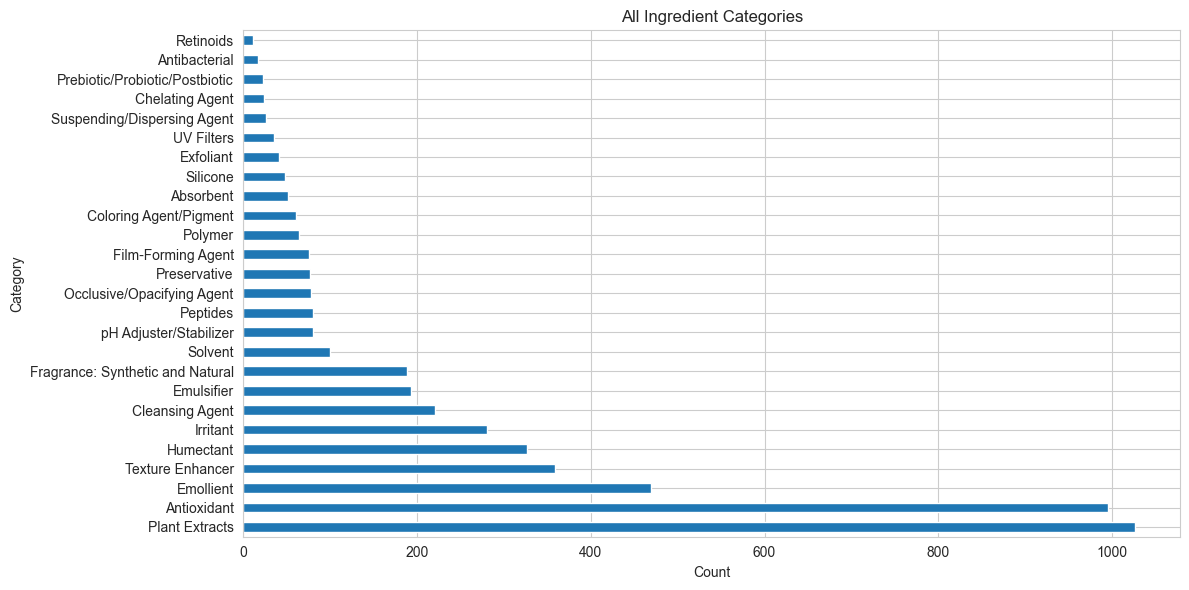

Total unique categories: 26


In [1378]:
# Extract all categories
all_categories = []
for categories_list in df['categories']:
    all_categories.extend(categories_list)

# Count them
category_counts = pd.Series(all_categories).value_counts()

# Plot
plt.figure()
category_counts.plot(kind='barh')
plt.title('All Ingredient Categories')
plt.xlabel('Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

print(f"Total unique categories: {len(category_counts)}")

#  Benefits Overview

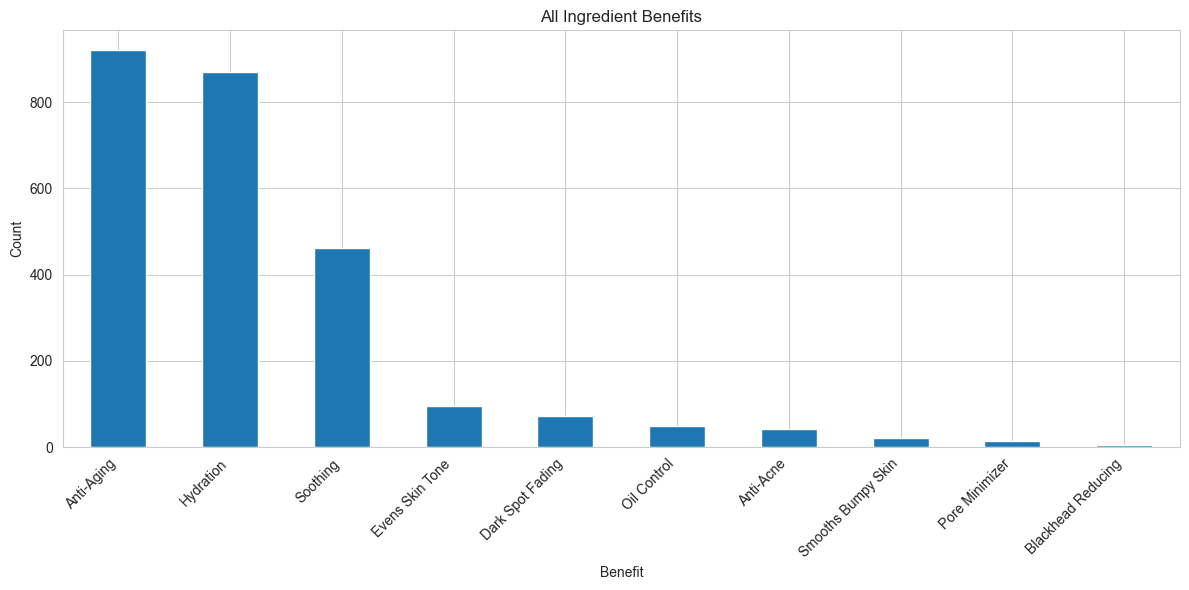

Total unique benefits: 10
Anti-Aging            920
Hydration             870
Soothing              461
Evens Skin Tone        95
Dark Spot Fading       72
Oil Control            49
Anti-Acne              41
Smooths Bumpy Skin     20
Pore Minimizer         15
Blackhead Reducing      4
Name: count, dtype: int64


In [1379]:
# Extract all benefits
all_benefits = []
for benefits_list in df['benefits']:
    all_benefits.extend(benefits_list)

# Count benefits
benefit_counts = pd.Series(all_benefits).value_counts()

# Plot 2a: Bar chart of all benefits
plt.figure()
benefit_counts.plot(kind='bar')
plt.title('All Ingredient Benefits')
plt.xlabel('Benefit')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Total unique benefits: {len(benefit_counts)}")
print(benefit_counts)

## benefits per ingredient

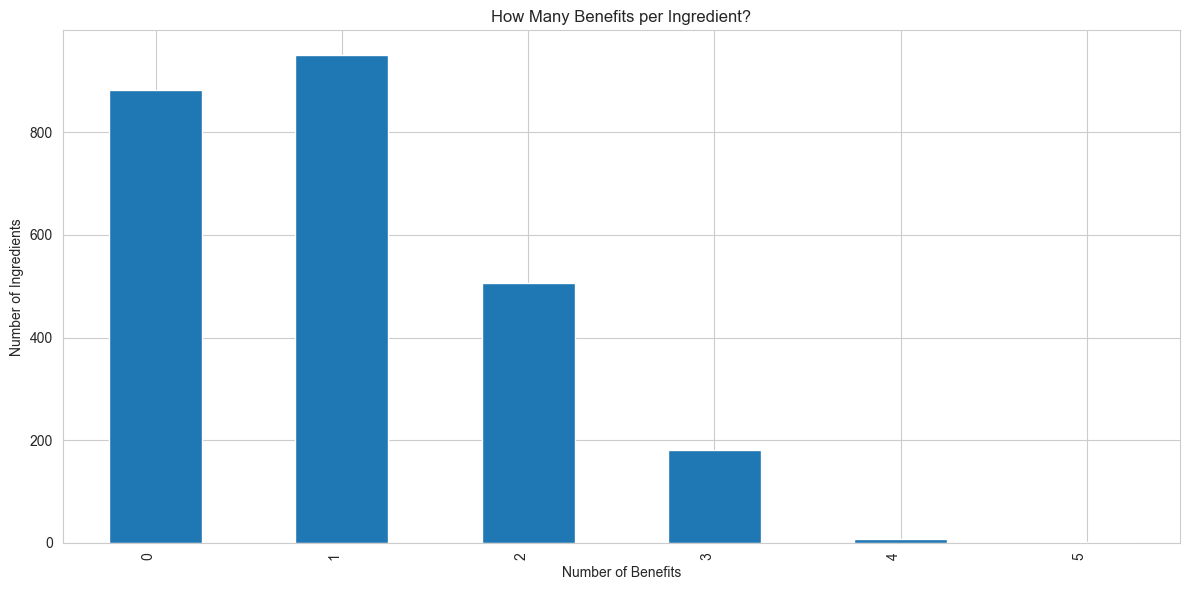

Breakdown:
  0 benefits: 882 ingredients (34.9%)
  1 benefits: 951 ingredients (37.6%)
  2 benefits: 506 ingredients (20.0%)
  3 benefits: 182 ingredients (7.2%)
  4 benefits: 7 ingredients (0.3%)
  5 benefits: 2 ingredients (0.1%)


In [1380]:
benefit_lengths = []
for benefits_list in df['benefits']:
    benefit_lengths.append(len(benefits_list))

# Count how many ingredients have 0, 1, 2, 3, 4 benefits
benefit_counts_per_num = pd.Series(benefit_lengths).value_counts().sort_index()

# Plot
plt.figure()
benefit_counts_per_num.plot(kind='bar')
plt.title('How Many Benefits per Ingredient?')
plt.xlabel('Number of Benefits')
plt.ylabel('Number of Ingredients')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

print("Breakdown:")
for num_benefits, count in benefit_counts_per_num.items():
    print(f"  {num_benefits} benefits: {count} ingredients ({count/len(df)*100:.1f}%)")

## Rating vs Categories

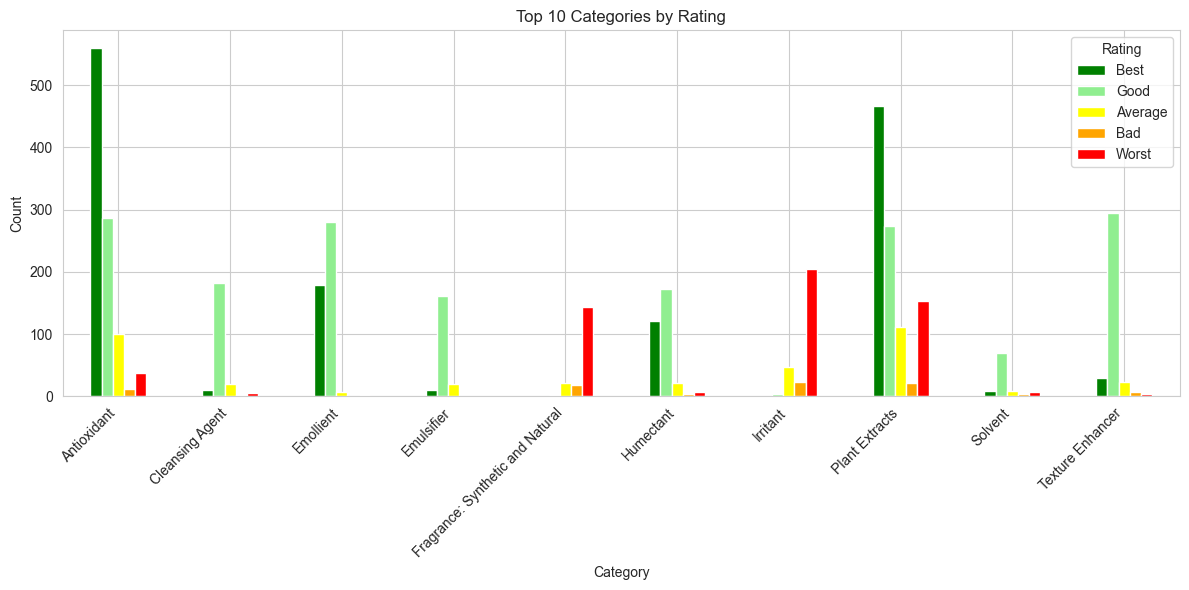

In [1381]:
#categories (each category gets own row)
rows = []
for idx, row in df.iterrows():
    for category in row['categories']:
        rows.append({
            'category': category,
            'rating': row['rating']
        })

df_exploded = pd.DataFrame(rows)


top_10_cats = df_exploded['category'].value_counts().head(10).index.tolist()
df_top = df_exploded[df_exploded['category'].isin(top_10_cats)]

# count ingredients per category per rating
count_data = df_top.groupby(['category', 'rating']).size().reset_index(name='count')

# Pivot for grouped bar
pivot_data = count_data.pivot(index='category', columns='rating', values='count').fillna(0)

# Sort columns by rating order
rating_order = ['Best', 'Good', 'Average', 'Bad', 'Worst']

existing_ratings = []
for col in rating_order:
    if col in pivot_data.columns:
        existing_ratings.append(col)

pivot_data = pivot_data[existing_ratings]

# Plot with custom colors
colors = {
    'Best': 'green',
    'Good': 'lightgreen', 
    'Average': 'yellow',
    'Bad': 'orange',
    'Worst': 'red'
}

pivot_data.plot(kind='bar', color=[colors[col] for col in pivot_data.columns])
plt.title('Top 10 Categories by Rating')
plt.xlabel('Category')
plt.ylabel('Count')
plt.legend(title='Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Ingredient Group Combinations

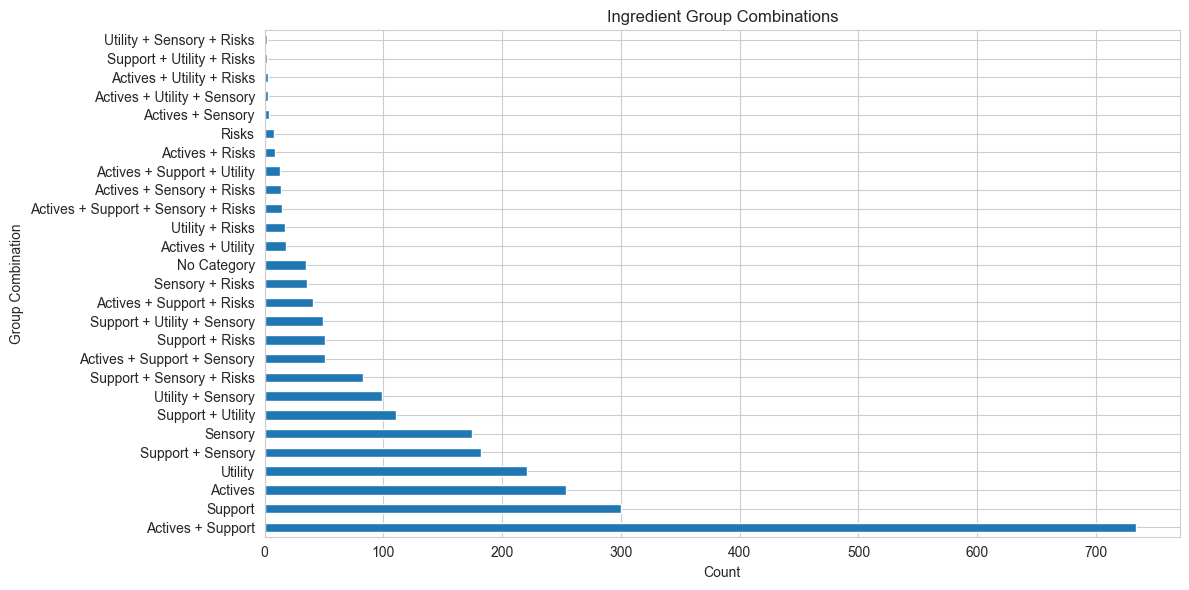

All combinations:
Actives + Support                  :  734 ( 29.0%)
Support                            :  300 ( 11.9%)
Actives                            :  254 ( 10.0%)
Utility                            :  221 (  8.7%)
Support + Sensory                  :  182 (  7.2%)
Sensory                            :  175 (  6.9%)
Support + Utility                  :  111 (  4.4%)
Utility + Sensory                  :   99 (  3.9%)
Support + Sensory + Risks          :   83 (  3.3%)
Actives + Support + Sensory        :   51 (  2.0%)
Support + Risks                    :   51 (  2.0%)
Support + Utility + Sensory        :   49 (  1.9%)
Actives + Support + Risks          :   41 (  1.6%)
Sensory + Risks                    :   36 (  1.4%)
No Category                        :   35 (  1.4%)
Actives + Utility                  :   18 (  0.7%)
Utility + Risks                    :   17 (  0.7%)
Actives + Support + Sensory + Risks:   15 (  0.6%)
Actives + Sensory + Risks          :   14 (  0.6%)
Actives + Sup

In [1382]:
# Create group labels from functional_group column
group_labels = []
for groups in df_final['functional_group']:
    if len(groups) == 0:
        group_labels.append('No Category')
    else:
        group_labels.append(' + '.join(groups))

# Count combinations
group_counts = pd.Series(group_labels).value_counts()

# Plot
plt.figure(figsize=(12, 6))
group_counts.plot(kind='barh')
plt.title('Ingredient Group Combinations')
plt.xlabel('Count')
plt.ylabel('Group Combination')
plt.tight_layout()
plt.show()

print("All combinations:")
for combo, count in group_counts.items():
    pct = count / len(df_final) * 100
    print(f"{combo:35s}: {count:4d} ({pct:5.1f}%)")

## Which categories deliver which benefits?

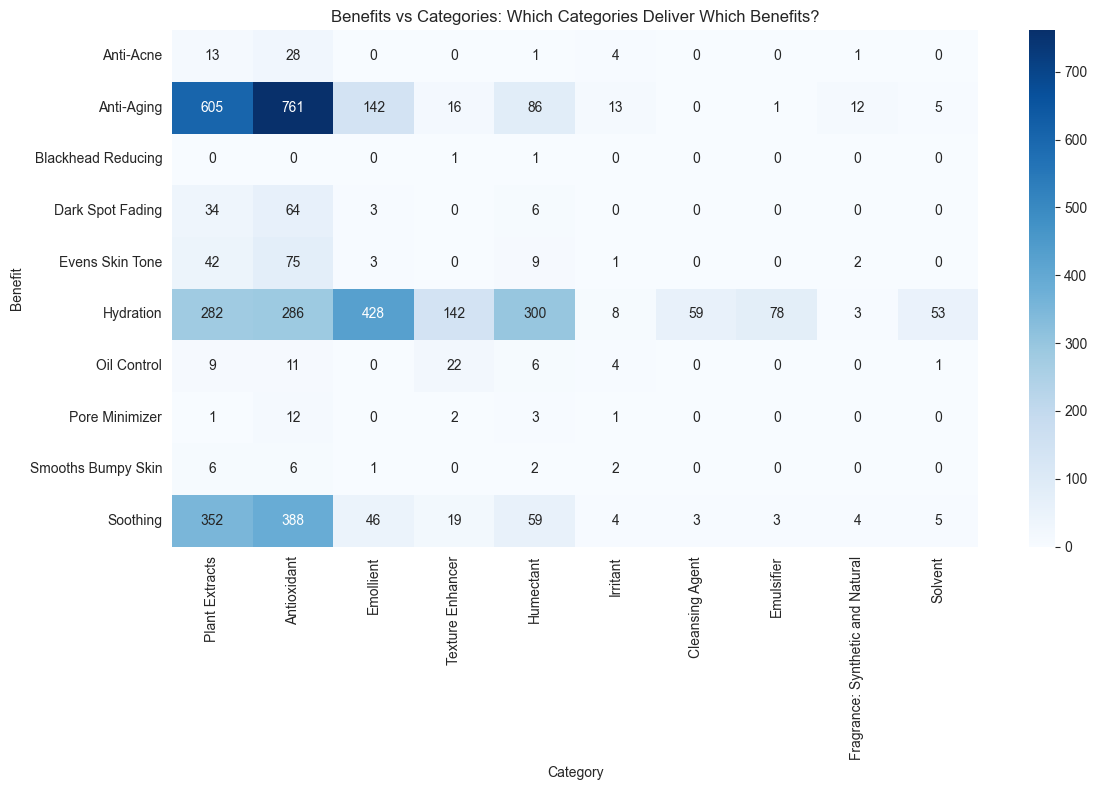

In [1383]:
# Explode both benefits and categories
rows = []
for idx, row in df.iterrows():
    for benefit in row['benefits']:
        for category in row['categories']:
            rows.append({
                'benefit': benefit,
                'category': category
            })

df_exploded = pd.DataFrame(rows)

# Count cooccurrences
benefit_cat_counts = df_exploded.groupby(['benefit', 'category']).size().reset_index(name='count')

# Pivot for heatmap
heatmap_data = benefit_cat_counts.pivot(index='benefit', columns='category', values='count').fillna(0)

# Keep top 10 categories only (most common)
all_cats = []
for cats in df['categories']:
    all_cats.extend(cats)
top_10_cats = pd.Series(all_cats).value_counts().head(10).index.tolist()
heatmap_data = heatmap_data[[col for col in top_10_cats if col in heatmap_data.columns]]

# Plot
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='Blues', annot=True, fmt='.0f')
plt.title('Benefits vs Categories: Which Categories Deliver Which Benefits?')
plt.xlabel('Category')
plt.ylabel('Benefit')
plt.tight_layout()
plt.show()

## Rating Distribution

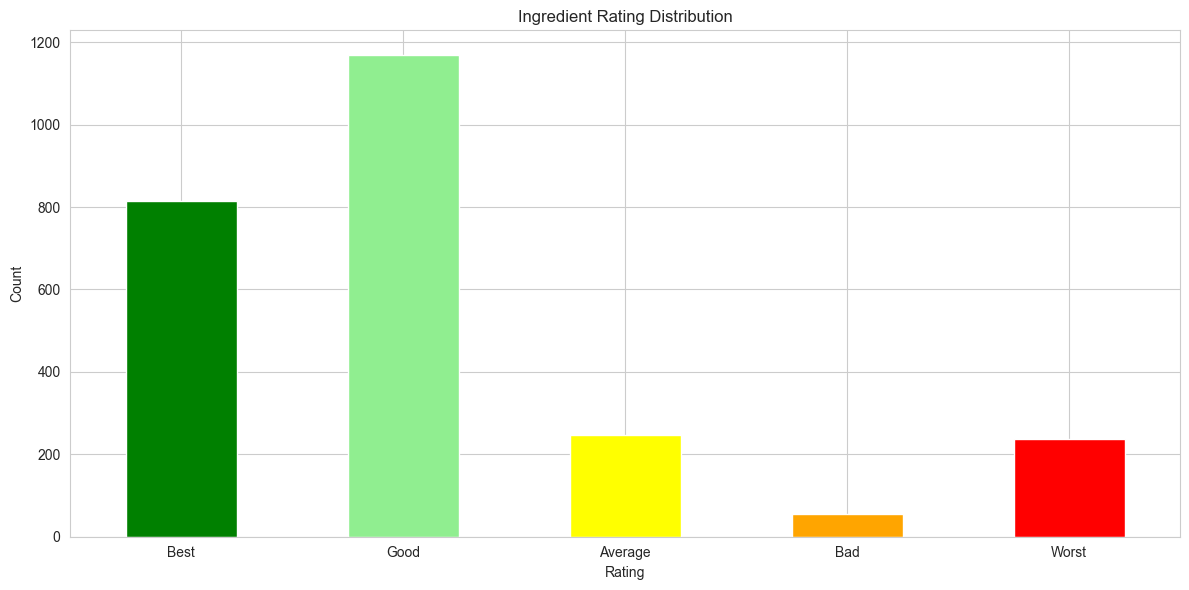

In [1384]:
rating_counts = df['rating'].value_counts()

# Sort by rating order
rating_order = ['Best', 'Good', 'Average', 'Bad', 'Worst']
existing_ratings = []
for rating in rating_order:
    if rating in rating_counts.index:
        existing_ratings.append(rating)

rating_counts_sorted = rating_counts[existing_ratings]

# Plot
plt.figure()
rating_counts_sorted.plot(kind='bar', color=['green', 'lightgreen', 'yellow', 'orange', 'red'])
plt.title('Ingredient Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [1385]:
for rating, count in rating_counts_sorted.items():
    pct = count / len(df[df['rating'].notna()]) * 100
    print(f"{rating}: {count} ({pct:.1f}%)")

Best: 814 (32.2%)
Good: 1170 (46.3%)
Average: 248 (9.8%)
Bad: 56 (2.2%)
Worst: 237 (9.4%)


## Conclusion

Successfully cleaned and prepared the Paulas Choice ingredient dataset for use in my SkinGen skincare recommendation system project.

### Data Cleaning Summary

**Starting Point:**
- 2 scraped CSV files with potential duplicates and formatting issues
- 2543 total rows with mixed data quality

**Cleaning Steps:**
1. Removed non-ingredient entries (article titles)
2. Merged files and removed 11 duplicate ingredients
3. Fixed 1 missing ingredient name
4. Cleaned rating values (removed invalid entries)
5. Converted string data to structured lists:
   - Benefits: `"Benefits: Anti-Aging"` => `['Anti-Aging']`
   - Categories: `"Categories: Antioxidant, Humectant"` => `['Antioxidant', 'Humectant']`
   - Info: Split glued sentences into separate bullet points

**Final Clean Dataset:**
- **2530 unique ingredients**
- **0 duplicates, 0 missing names**
- **6 structured columns:** ingredient_name, rating, benefits (list), categories (list), info (list), functional_group (list)

### Feature Engineering

Added **functional_group** column to simplify the 26 raw categories into 5 actionable groups:

1. **Actives** (treatment ingredients): Retinoids, Peptides, Antioxidants, Exfoliants, UV Filters
2. **Support** (base moisturization): Humectants, Emollients, Plant Extracts  
3. **Utility** (product stability): Emulsifiers, Preservatives, pH stabilizers
4. **Sensory** (user experience): Fragrances, Texturizers, Colorants
5. **Risks** (potential irritants): Irritants

This feature encodes skincare domain knowledge into the dataset and simplifies future recommendation logic (eg prioritize "Actives" for anti-aging concerns, filter "Risks" for sensitive skin).

### Key Insights from EDA

**Rating Distribution:**
- Good: 1170 ingredients (46%)
- Best: 814 ingredients (32%)
- Average: 248 ingredients (10%)
- Worst: 237 ingredients (9%)
- Bad: 56 ingredients (2%)

**Ingredient Composition:**
- Most ingredients are **multi-functional**: 734 ingredients combine "Actives + Support"
- Pure categories are rare: only 254 pure "Actives", 300 pure "Support"
- This validates that skincare ingredients serve multiple purposes simultaneously

**Category-Benefit Correlations:**
- Antioxidants => Anti-Aging (761 occurrences)
- Humectants => Hydration (300 occurrences)
- Emollients => Hydration (428 occurrences)
- Plant Extracts deliver the widest range of benefits (multi-functional actives)

These correlations confirm that our functional grouping aligns with real skincare science.

### Output

**Saved File:** `ingredients_cleaned.parquet`

**Data Structure:**
```
ingredient_name (string): "Niacinamide"
rating (string): "Best"
benefits (list): ['Anti-Aging', 'Hydration']
categories (list): ['Antioxidant', 'Humectant']
info (list): ['Form of vitamin B3', 'Reduces inflammation', ...]
functional_group (list): ['Actives', 'Support']
```

### Next Steps

1. Load product dataset
2. Join products with ingredient data
3. Implement recommendation scoring logic using functional groups
4. Build filtering system based on user preferences (skin type, concerns, sensitivities)

This cleaned dataset serves as the foundation for the SkinGen ingredient intelligence layer, enabling data-driven skincare product recommendations.